# 1. Pengumpulan Data

In [ ]:
!pip install google-play-scraper

In [ ]:
from google_play_scraper import app
from google_play_scraper import Sort, reviews
result, continuation_token = reviews(
    'com.levelinfinite.hotta.gp', #id aplikasi
    lang='id', # bahasa - defaults to 'en'
    country='id', # negara - defaults to 'us'
    sort=Sort.NEWEST, # tipe sort = Sort.MOST_RELEVANT / Sort.NEWEST
    count=2000, # jumlah data yang di inginkan
    filter_score_with=None # memilih score pasti, default None
)

In [ ]:
import pandas as pd
import numpy as np
df_rawdatatof = pd.DataFrame(np.array(result),columns=['review']) #membuat dataframe untuk menapung 'result' di kolom review
df_rawdatatof = df_rawdatatof.join(pd.DataFrame(df_rawdatatof.pop('review').tolist())) #memecah kolom 'review' (yang berupa list/dictionary) menjadi kolom-kolom terpisah
df_rawdatatofsorted = df_rawdatatof.sort_values(by='at', ascending=False) # sort dari yang terbaru hingga terlama/descending
df_rawdatatofsorted #menampilkan dataframe

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,b0ebceac-0bc5-4b81-a204-04c8280b9248,Muh.aditya,https://play-lh.googleusercontent.com/a/ACg8oc...,game bagus ringan,5,0,NaN,2025-05-31 03:00:20,NaN,NaN,NaN
1,b791b7af-1ae4-4e00-9a0e-f03889d32810,lalalu ayu,https://play-lh.googleusercontent.com/a/ACg8oc...,Dari dulu memang suka game MMO. Sayangnya dari...,3,0,NaN,2025-05-31 01:56:00,NaN,NaN,NaN
2,c5a884fc-7ce7-4c2c-94f2-356b1fc8d7c5,day,https://play-lh.googleusercontent.com/a-/ALV-U...,"ribet loginnya, gak bisa masuk",1,0,5.0.0,2025-05-30 14:03:46,NaN,NaN,5.0.0
3,75ceb987-c561-4368-a7a8-43ad72d67ff7,KENZZ TURU,https://play-lh.googleusercontent.com/a-/ALV-U...,developer sekarang terlalu pelit mending devel...,1,0,2.2.0,2025-05-30 07:07:35,NaN,NaN,2.2.0
4,234e92c8-3919-4941-acd3-3c564928212f,MixPanZuzu,https://play-lh.googleusercontent.com/a/ACg8oc...,Menurut aku game ini udah bagus.. tpi yang per...,1,1,5.0.0,2025-05-30 01:02:22,NaN,NaN,5.0.0
...,...,...,...,...,...,...,...,...,...,...,...
1995,40d9b09f-0565-4463-9981-5c85406b759d,David Syachputra,https://play-lh.googleusercontent.com/a-/ALV-U...,Sebenernya udh bagus dari segi grafik sama in ...,3,0,NaN,2023-04-08 02:06:48,Kami menyesal mendengar bahwa Anda mengalami p...,2023-04-08 08:30:40,NaN
1996,88014845-984f-44dd-aabc-7d5b66ce6e25,Muh Fadly,https://play-lh.googleusercontent.com/a/ACg8oc...,"Ini kok ga bisa login ke in game nya sih min,a...",1,0,2.4.0,2023-04-07 21:17:55,"Hai Wanderer, terima kasih telah meluangkan wa...",2023-04-08 08:34:32,2.4.0
1997,14f3273e-3450-40dd-a526-93fdd43612c6,RPG. Kouganz_,https://play-lh.googleusercontent.com/a/ACg8oc...,the best,5,0,2.4.0,2023-04-07 16:11:11,NaN,NaN,2.4.0
1998,08bc0f85-18b7-4fc8-86d0-9e8ef65508ca,dwiki juliansyah,https://play-lh.googleusercontent.com/a-/ALV-U...,Mantab gacha ku wangy,5,0,2.4.0,2023-04-07 15:24:56,NaN,NaN,2.4.0


In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

new_tof2kreview_df = df_rawdatatofsorted[['at', 'content', 'score']].rename(columns={
    'score': 'rating',
    'at': 'tanggalDibuat',
    'content': 'ulasan'
})
new_tof2kreview_df.head(5) #menampilkan dataframe

# 2. Pelabelan Data

In [ ]:
labeled_tof2kreview_df = new_tof2kreview_df.copy() #copy df
def give_label(rating): # fungsi pemberian label
    if rating <= 3:
        return 'negatif'
    else:
        return 'positif'

labeled_tof2kreview_df['label'] = labeled_tof2kreview_df['rating'].apply(give_label) #apply pakai fungsi
labeled_tof2kreview_df.head(5) #menampilkan df

# 3. Preprocessing data

## 1. Case Folding

In [ ]:
casefolded_tof2kreview_df = labeled_tof2kreview_df #copy df
casefolded_tof2kreview_df['ulasanCaseFolding'] = casefolded_tof2kreview_df['ulasan'].str.lower() #mengubah semua konten di kolom content menjadi lowercase dan menyimpan di kolum contentCaseFolding
casefolded_tof2kreview_df[["ulasan", "ulasanCaseFolding"]].head(5) #menampilkan df

## 2. Cleaning

In [ ]:
import re
def clean_text(text): 
    text = re.sub(r'[0-9]+', ' ', text) 
    text = re.sub(r"[-()\"#/@;:<>{}%'+=~|.!?,_]", " ", text) 
    text = re.sub(r'[^\x00-\x7F]+', ' ', text) 
    text = re.sub(r'\s+', ' ', text) 
    text = text.strip(' ')  
    return text

cleaned_tof2kreview_df = casefolded_tof2kreview_df.copy()

cleaned_tof2kreview_df['ulasanCleaning'] = (
    cleaned_tof2kreview_df['ulasanCaseFolding'].apply(clean_text)
)
cleaned_tof2kreview_df = cleaned_tof2kreview_df[
    cleaned_tof2kreview_df['ulasanCleaning'] != ''
]
cleaned_tof2kreview_df[["ulasanCaseFolding","ulasanCleaning"]].head(5) 

## 3. Normalization

In [ ]:
!pip install indoNLP
slang_map = {
    "dnlwd":"download",
    "wangy":"wangi",
    "mantab":"mantap"
}
from indoNLP.preprocessing import replace_slang, replace_word_elongation
def replace_slang_word(text):
  #custom additional map
  for word, replacement in slang_map.items():
      text = text.replace(word, replacement)

  text = replace_slang(text)
  text = replace_word_elongation(text)
  return text

normalize_tof2kreview_df = cleaned_tof2kreview_df.copy()
normalize_tof2kreview_df['ulasanNormalization'] = (
    normalize_tof2kreview_df['ulasanCleaning'].apply(replace_slang_word)
)
normalize_tof2kreview_df[["ulasanCleaning","ulasanNormalization"]].head(5)

## 4. Stopword Removal

In [ ]:
# Additional stopwords credits: https://github.com/masdevid/ID-Stopwords
new_stopwords = [
    "nya", "yg", "jd", "jadi", "gk", "gak", "kok", "gb", "di", "aja", "pas", "aa", "abd", "abai", "anjir","buset", "nih", "the","min","aj",
    "adalah", "adanya", "adapun", "agak", "agaknya", "agar", "akan", "akankah",
    "akhir", "akhiri", "akhirnya", "aku", "akulah", "amat", "amatlah", "anda", "andalah",
    "antar", "antara", "antaranya", "apa", "apaan", "apabila", "apakah", "apalagi", "apatah",
    "artinya", "asal", "asalkan", "atas", "atau", "ataukah", "ataupun", "awal", "awalnya",
    "bagai", "bagaikan", "bagaimana", "bagaimanakah", "bagaimanapun", "bagi", "bagian", "bahkan",
    "bahwa", "bahwasanya", "bakal", "bakalan", "balik", "banyak", "bapak", "baru",
    "bawah", "beberapa", "begini", "beginian", "beginikah", "beginilah", "begitu", "begitukah",
    "begitulah", "begitupun", "bekerja", "belakang", "belakangan", "belum", "belumlah", "benar", "bisa",
    "benarkah", "benarlah", "berada", "berakhir", "berakhirlah", "berakhirnya", "berapa",
    "berapakah", "berapalah", "berapapun", "berarti", "berawal", "berbagai", "berdatangan", "beri",
    "berikan", "berikut", "berikutnya", "berjumlah", "berkali-kali", "berkata", "berkehendak",
    "berkeinginan", "berkenaan", "berlainan", "berlalu", "berlangsung", "berlebihan", "bermacam",
    "bermacam-macam", "bermaksud", "bermula", "bersama", "bersama-sama", "bersiap", "bersiap-siap",
    "bertanya", "bertanya-tanya", "berturut", "berturut-turut", "bertutur", "berujar", "berupa",
    "besar", "betul", "betulkah", "biasa", "biasanya", "bila", "bilakah", "bisa", "bisakah",
    "boleh", "bolehkah", "bolehlah", "buat", "bukan", "bukankah", "bukanlah", "bukannya", "bulan",
    "bung", "cara", "caranya", "cukup", "cukupkah", "cukuplah", "cuma", "dahulu", "dalam", "dan",
    "dapat", "dari", "daripada", "datang", "dekat", "demi", "demikian", "demikianlah", "dengan",
    "depan", "dia", "diakhiri", "diakhirinya", "dialah", "diantara", "diantaranya", "diberi",
    "diberikan", "diberikannya", "dibuat", "dibuatnya", "didapat", "didatangkan", "digunakan",
    "diibaratkan", "diibaratkannya", "diingat", "diingatkan", "diinginkan", "dijawab",
    "dijelaskan", "dijelaskannya", "dikarenakan", "dikatakan", "dikatakannya", "dikerjakan",
    "diketahui", "diketahuinya", "dikira", "dilakukan", "dilalui", "dilihat", "dimaksud",
    "dimaksudkan", "dimaksudkannya", "dimaksudnya", "diminta", "dimintai", "dimisalkan", "dimulai",
    "dimulailah", "dimulainya", "dimungkinkan", "dini", "dipastikan", "diperbuat", "diperbuatnya",
    "dipergunakan", "diperkirakan", "diperlihatkan", "diperlukan", "diperlukannya", "dipersoalkan",
    "dipertanyakan", "dipunyai", "diri", "dirinya", "disampaikan", "disebut", "disebutkan",
    "disebutkannya", "disini", "disinilah", "ditambahkan", "ditandaskan", "ditanya", "ditanyai",
    "ditanyakan", "ditegaskan", "ditujukan", "ditunjuk", "ditunjuki", "ditunjukkan",
    "ditunjukkannya", "ditunjuknya", "dituturkan", "dituturkannya", "diucapkan", "diucapkannya",
    "diungkapkan", "dong", "dua", "dulu", "empat", "enggak", "enggaknya", "entah", "entahlah",
    "guna", "gunakan", "hal", "hampir", "hanya", "hanyalah", "hari", "harus", "haruslah",
    "harusnya", "hendak", "hendaklah", "hendaknya", "hingga", "ia", "ialah", "ibarat", "ibaratkan",
    "ibaratnya", "ibu", "ikut", "ingat", "ingat-ingat", "ingin", "inginkah", "inginkan", "ini",
    "inikah", "inilah", "itu", "itukah", "itulah", "jadilah", "jadinya", "jangan", "jangankan",
    "janganlah", "jauh", "jawab", "jawaban", "jawabnya", "jelas", "jelaskan", "jelaslah",
    "jelasnya", "jika", "jikalau", "juga", "jumlah", "jumlahnya", "justru", "kala", "kalau", "kalo",
    "kalaulah", "kalaupun", "kalian", "kami", "kamilah", "kamu", "kamulah", "kan", "kapan",
    "kapankah", "kapanpun", "karena", "karenanya", "kasus", "kata", "katakan", "katakanlah",
    "katanya", "ke", "keadaan", "kebetulan", "kecil", "kedua", "keduanya", "keinginan", "kelamaan",
    "kelihatan", "kelihatannya", "kelima", "kembali", "kemudian", "kemungkinan",
    "kemungkinannya", "kenapa", "kepada", "kepadanya", "kesampaian", "keseluruhan",
    "keseluruhannya", "keterlaluan", "ketika", "khususnya", "kini", "kinilah", "kira", "kira-kira",
    "kiranya", "kita", "kitalah", "kurang", "lagi", "lagian", "lah", "lain", "lainnya", "lalu",
    "lama", "lamanya", "lanjut", "lanjutnya", "lebih", "lewat", "lima", "luar", "macam", "maka",
    "makanya", "makin", "malah", "malahan", "mampu", "mampukah", "mana", "manakala", "manalagi",
    "masa", "masalahnya", "masih", "masihkah", "masing", "masing-masing", "mau",
    "maupun", "melainkan", "melakukan", "melalui", "melihat", "melihatnya", "memang", "memastikan",
    "memberi", "memberikan", "membuat", "memerlukan", "memihak", "meminta", "memintakan",
    "memisalkan", "memperbuat", "mempergunakan", "memperkirakan", "memperlihatkan",
    "mempersiapkan", "mempersoalkan", "mempertanyakan", "mempunyai", "memulai", "memungkinkan",
    "menaiki", "menambahkan", "menandaskan", "menanti", "menanti-nanti", "menantikan", "menanya",
    "menanyai", "menanyakan", "mendapat", "mendapatkan", "mendatang", "mendatangi", "mendatangkan",
    "menegaskan", "mengakhiri", "mengapa", "mengatakan", "mengatakannya", "mengenai",
    "mengerjakan", "mengetahui", "menggunakan", "menghendaki", "mengibaratkan",
    "mengibaratkannya", "mengingat", "mengingatkan", "menginginkan", "mengira", "mengucapkan",
    "mengucapkannya", "mengungkapkan", "menjadi", "menjawab", "menjelaskan", "menuju", "menunjuk",
    "menunjuki", "menunjukkan", "menunjuknya", "menurut", "menuturkan", "menyampaikan",
    "menyangkut", "menyatakan", "menyebutkan", "menyeluruh", "menyiapkan", "merasa", "mereka",
    "merekalah", "merupakan", "meski", "meskipun", "meyakini", "meyakinkan", "minta", "mirip",
    "misal", "misalkan", "misalnya", "mula", "mulai", "mulailah", "mulanya", "mungkin",
    "mungkinkah", "nah", "naik", "namun", "nanti", "nantinya", "nyaris", "nyatanya", "oleh",
    "olehnya", "pada", "padahal", "padanya", "pak", "paling", "panjang", "pantas", "para", "pasti",
    "pastilah", "penting", "pentingnya", "per", "percuma", "perlu", "perlukah", "perlunya",
    "pernah", "persoalan", "pertama", "pertama-tama", "pertanyaan", "pertanyakan", "pihak",
    "pihaknya", "pukul", "pula", "pun", "punya", "rasa", "rasanya", "rata", "rupanya", "saat",
    "saatnya", "saja", "sajalah", "saling", "sama", "sama-sama", "sambil", "sampai", "sampai-sampai",
    "sampaikan", "sana", "sangat", "sangatlah", "satu", "saya", "sayalah", "se", "sebab", "sebabnya",
    "sebagai", "sebagaimana", "sebagainya", "sebagian", "sebaik", "sebaik-baiknya", "sebaiknya",
    "sebaliknya", "sebanyak", "sebegini", "sebegitu", "sebelum", "sebelumnya", "sebenarnya",
    "seberapa", "sebesar", "sebetulnya", "sebisanya", "sebuah", "sebut", "sebutlah", "sebutnya",
    "secara", "secukupnya", "sedang", "sedangkan", "sedemikian", "sedikit", "sedikitnya",
    "seenaknya", "segala", "segalanya", "segera", "seharusnya", "sehingga", "seingat", "sejak",
    "sejauh", "sejenak", "sejumlah", "sekadar", "sekadarnya", "sekali", "sekali-kali", "sekalian",
    "sekaligus", "sekalipun", "sekarang", "sekecil", "seketika", "sekiranya", "sekitar",
    "sekitarnya", "sekurang-kurangnya", "sekurangnya", "sela", "selain", "selaku", "selalu",
    "selama", "selama-lamanya", "selamanya", "selanjutnya", "seluruh", "seluruhnya", "semacam",
    "semakin", "semampu", "semampunya", "semasa", "semasih", "semata", "semata-mata", "semaunya",
    "sementara", "semisal", "semisalnya", "sempat", "semua", "semuanya", "semula", "sendiri",
    "sendirian", "sendirinya", "seolah", "seolah-olah", "seorang", "sepanjang", "sepantasnya",
    "sepantasnyalah", "seperlunya", "seperti", "sepertinya", "sepihak", "sering", "seringnya",
    "serta", "serupa", "sesaat", "sesama", "sesampai", "sesegera", "sesekali", "seseorang",
    "sesuatu", "sesuatunya", "sesudah", "sesudahnya", "setelah", "setempat", "setengah",
    "seterusnya", "setiap", "setiba", "setibanya", "setidak-tidaknya", "setidaknya", "setinggi",
    "seusai", "sewaktu", "siap", "siapa", "siapakah", "siapapun", "sini", "sinilah", "soal",
    "soalnya", "suatu", "sudah", "sudahkah", "sudahlah", "supaya", "tadi", "tadinya", "tahu",
    "tahun", "tak", "tambah", "tambahnya", "tampak", "tampaknya", "tandas", "tandasnya", "tanpa",
    "tanya", "tanyakan", "tanyanya", "tapi", "tegas", "tegasnya", "telah", "tempat", "tengah", "tarik",
    "tentang", "tentu", "tentulah", "tentunya", "tepat", "terakhir", "terasa", "terbanyak",
    "terdahulu", "terdapat", "terdiri", "terhadap", "terhadapnya", "teringat", "teringat-ingat",
    "terjadi", "terjadilah", "terjadinya", "terkira", "terlalu", "terlebih", "terlihat",
    "termasuk", "ternyata", "tersampaikan", "tersebut", "tersebutlah", "tertentu", "tertuju",
    "terus", "terutama", "tetap", "tetapi", "tiap", "tiba", "tiba-tiba", "tidakkah", "tidak",
    "tidaklah", "tiga", "tinggi", "toh", "tunjuk", "turut", "tutur", "tuturnya", "ucap", "ucapnya", "udah",
    "ujar", "ujarnya", "umum", "umumnya", "ungkap", "ungkapnya", "untuk", "usah", "usai", "waduh",
    "wah", "wahai", "waktu", "waktunya", "walau", "walaupun", "wong", "yaitu", "yakin", "yakni",
    "yang", "sih", "moga","kenapa","udh","kalo","gw","kali","dan","dah","ini","padahal","kadang","jadi","kasih","tapi","lagi",
    "sebelah","ganti","gua","ku","ya","ni","cuman","mulu","coba","ga","of","biar","mohon","this", "gimana","sampe","kayak","in","suruh","bgt","bikin","banget", "tuh", "kek", "kalo", "asa",
    "gin", "tpi", "dll", "eh", "ting", "gitu", "segi", "nge","tau","lu","klo","trus","lg", "ada" , "gue", "gb", "ting", "deh"
]

def remove_stopwords(text):
    return ' '.join([word for word in text.split() if word not in new_stopwords])
# copy df
stopwordremove_tof2kreview_df = normalize_tof2kreview_df.copy()

stopwordremove_tof2kreview_df['ulasanStopwordRemoval'] = \
  stopwordremove_tof2kreview_df['ulasanNormalization'].apply(remove_stopwords)
stopwordremove_tof2kreview_df = stopwordremove_tof2kreview_df[
  stopwordremove_tof2kreview_df['ulasanStopwordRemoval'] != ''
]
stopwordremove_tof2kreview_df[["ulasanNormalization","ulasanStopwordRemoval"]].head(5)

## 5. Stemming

In [ ]:
# Custom mapping
custom_base_word_map = {
    'gamenya': 'game',
    'gachanya': 'gacha',
    'ngelag': 'lag',
    'bugnya': 'bug',
    'ngebug' : 'bug',
    'mainin' : 'main',
    'loginnya' : 'login'
}

!pip install Sastrawi
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
# Inisialisasi stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def custom_stem(text):
    for word, replacement in custom_base_word_map.items():
        text = text.replace(word, replacement)
    text = stemmer.stem(text)
    return text

# copy df
stemmed_tof2kreview_df = stopwordremove_tof2kreview_df.copy()

stemmed_tof2kreview_df['ulasanStemmed'] = \
    stemmed_tof2kreview_df['ulasanStopwordRemoval'].apply(custom_stem)

stemmed_tof2kreview_df[["ulasanStopwordRemoval","ulasanStemmed"]].head(5)

## 6. Tokenize

In [ ]:
def tokenize(text):
    return text.split()

tokenize_tof2kreview_df = stemmed_tof2kreview_df.copy()
tokenize_tof2kreview_df['ulasanTokenize'] = (
    tokenize_tof2kreview_df['ulasanStemmed'].apply(tokenize)
)
tokenize_tof2kreview_df[["ulasanStemmed","ulasanTokenize"]].head(5)

# 4. Visualisasi

In [ ]:
import matplotlib.pyplot as plt
# Hitung jumlah label
label_counts = tokenize_tof2kreview_df['label'].value_counts()
labels = ['Negatif', 'Positif']
counts = label_counts.to_numpy()
total = counts.sum()
# fungsi value count
def fmt(x):
    return '{:.1f}%\n({:.0f})'.format(x, total * x / 100)

plt.figure(figsize=(6, 6))
plt.pie(
    counts,
    labels=labels,
    autopct=fmt,
    explode=[0.02, 0.02],
    startangle=90,
    colors=['salmon', 'lightgreen'],
    textprops={'fontsize': 14}
)
plt.title('Perbandingan Ulasan Positif dan Negatif', fontsize=16)
plt.axis('equal')
plt.show()

In [ ]:
from wordcloud import WordCloud


positif_text = " ".join(
    token for ulasan in tokenize_tof2kreview_df[tokenize_tof2kreview_df['label'] == 'positif']['ulasanTokenize']
    for token in ulasan
)


positif_wc = WordCloud(
    width=800, height=600, background_color="white", collocations=False, normalize_plurals=False
).generate(positif_text)

plt.figure(figsize=(8, 6))
plt.imshow(positif_wc)
plt.title("Wordcloud Positif")
plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:

negatif_text = " ".join(
    token for ulasan in tokenize_tof2kreview_df[tokenize_tof2kreview_df['label'] == 'negatif']['ulasanTokenize']
    for token in ulasan
)

negatif_wc = WordCloud(
    width=800, height=600, background_color="white", collocations=False, normalize_plurals=False
).generate(negatif_text)

plt.figure(figsize=(8, 6))
plt.imshow(negatif_wc)
plt.title("Wordcloud Negatif")
plt.axis("off")
plt.tight_layout()
plt.show()

# 5. Pembagian Data

In [ ]:
from sklearn.model_selection import train_test_split

ulasan = tokenize_tof2kreview_df['ulasanTokenize']
label = tokenize_tof2kreview_df['label']
X_train, X_test, y_train, y_test = train_test_split(ulasan, label, test_size=0.4, random_state=23) # 10 11 12 |13| -14- 15 17 19 _20_ _21_ || 19 21 [1 10 |12 23 31 35 37| 13 14 15 16 17 20 21]

# Menampilkan jumlah data latih dan uji
print("Pembagian data 60:40")
print("Jumlah Data Latih:", len(X_train))
print("Jumlah Data Uji:", len(X_test))

print("-\nData Latih:")
print(y_train.value_counts().to_string())

print("\n-\nData Uji")
print(y_test.value_counts().to_string())

Pembagian data 80:20
Jumlah Data Latih: 1181
Jumlah Data Uji: 788
-
Data Latih:
label
negatif    638
positif    543

-
Data Uji
label
negatif    454
positif    334


# 6. Pembobotan TF-IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(tokenizer=lambda x: x, lowercase=False)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

feature_names = tfidf_vectorizer.get_feature_names_out()
tfidf_sums = X_train_tfidf.sum(axis=0).A1
top_n = 10
top_indices = np.argsort(tfidf_sums)[::-1][:top_n]

print("10 Kata teratas bobot TF-IDF \nPembagian data 60:40 :")
for i in top_indices:
    print(f"{feature_names[i]}: {tfidf_sums[i]:.1f}")

10 Kata teratas bobot TF-IDF 
Pembagian data 60:40 :
game: 87.6
bagus: 70.9
main: 45.7
bug: 37.5
update: 36.4
tolong: 32.3
baik: 29.9
download: 27.8
akun: 25.3
data: 22.7


# 7. Klasifikasi Support Vector Machine

In [ ]:

from sklearn.metrics import classification_report 
from sklearn.metrics import accuracy_score  
from sklearn.svm import SVC

svm_classifier = SVC(kernel='linear')

svm_classifier.fit(X_train_tfidf, y_train)

predict = svm_classifier.predict(X_test_tfidf)

# accuracy = accuracy_score(y_test, predict)
# print(f"Accuracy: {accuracy}")
# print(classification_report(y_test, predict,digits=4))

# 8. Hasil Confusion Matrix

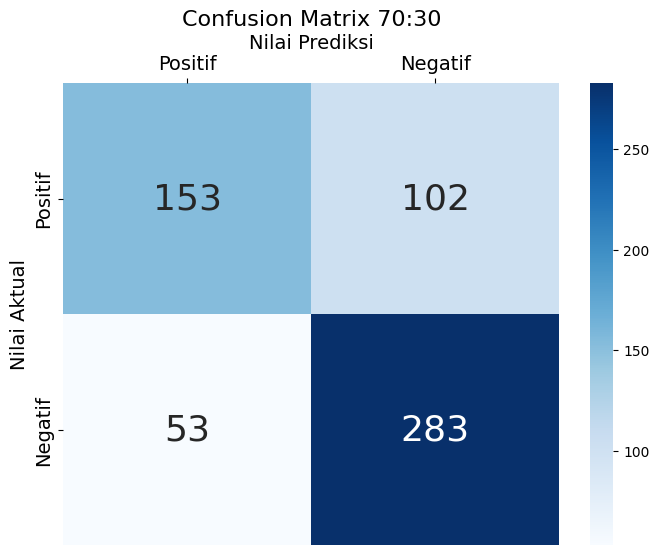

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, predict)
cm_flipped = cm[::-1, ::-1]
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_flipped,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Positif', 'Negatif'],
    yticklabels=['Positif', 'Negatif'],
    annot_kws={'fontsize': 26}
)
plt.title('Confusion Matrix 60:40', fontsize=16)
plt.xlabel('Nilai Prediksi', fontsize=14)
plt.ylabel('Nilai Aktual', fontsize=14)
plt.tick_params(axis='x', labelsize=14)
plt.tick_params(axis='y', labelsize=14)
plt.gca().xaxis.set_label_position('top')
plt.gca().xaxis.tick_top()

plt.show()